# Parallel bouquet over IMAS time slices

This is the 3-slice IMAS sweep from `bouquet_D3Dlike_omas_example.ipynb`, run
**in parallel across CPU cores**. Each draw is an independent Grad-Shafranov
solve, so the bouquet is embarrassingly parallel — the only constraint is that
OpenFUSIONToolkit's `OFT_env` is a **per-process singleton**, so we parallelize
across **processes** (each with its own TokaMaker), not threads.

**Why this is exact.** At `nthreads=1` the baseline forward-solve is
*bit-identical across processes* (verified: a fresh worker reproduces
`li_1`/`li_3`/`Ip`/`psi` to 0), so every worker re-solves the same baseline and
conditions its draws on it — no flux state needs to be shipped. `parallel_generate`
additionally **asserts** all workers landed on the same baseline `li`/`Ip`.

> Parallel draws are *not* bit-identical to a serial run of the same seed: each
> worker uses an independent RNG stream (`seed + worker_id`), so the union is a
> statistically-equivalent *different* draw set. The baseline is identical.

In [1]:
import os, copy, time
import numpy as np
import matplotlib.pyplot as plt
import bouquet as bq

%matplotlib inline
%config InlineBackend.figure_format = "retina"

OMAS = 'D3Dlike_baseline_omas.json'   # FUSE-style IMAS/OMAS data dictionary
MESH = 'DIIID_mesh.h5'                # TokaMaker finite-element mesh

# the 3 L->H slices, with the fake step labels [ms] used as the scan key / time axis
TIMES = [2.10, 2.20, 2.3043]
T2MS  = {2.10: 1600, 2.20: 1800, 2.3043: 2000}
SEED  = 12345
print('bouquet', bq.__version__, '| cores', os.cpu_count())

bouquet 1.3.1 | cores 10


## 1. Parallel configuration

Two knobs set the decomposition. The **oversubscription rule** is the whole
game: `n_workers × threads_per_worker` must not exceed the physical cores, or the
workers thrash and you lose the speed-up. `parallel_generate` pins each worker's
BLAS/OpenMP to `threads_per_worker` so a worker really uses that many cores
(without the pin, OFT runs single-threaded but the BLAS underneath grabs ~all
cores per worker — the classic "why is my parallel run *slower*" trap).

- `threads_per_worker = 1` keeps each worker single-threaded — both the *most
  reproducible* (`nthreads=1` is bit-deterministic) and the most parallel per
  core.
- `n_workers` defaults to **4** here, not all cores: each worker holds a full
  TokaMaker (mesh + sparse matrices ≈ a GB), so on a personal machine 4 keeps
  RAM in check. Bump it toward the core count on a workstation with headroom.
- `backend="laptop"` runs a `ProcessPoolExecutor` now; `backend="slurm"` emits a
  job-array script for a cluster (last section).

> **Runtime.** Each draw is a full GS + bootstrap + corrective solve (~3–4 min
> single-threaded), so `N_EQUILS × len(TIMES)` solves dominate the wall time. With
> the defaults below (8 × 3 = 24 solves over 4 workers) expect ~25–30 min; each
> worker also re-does one baseline solve, so halving `N_EQUILS` cuts ~40%, not 50%.
> Drop `N_EQUILS` further for a quick smoke run.

In [2]:
PARALLEL = dict(
    backend            = "laptop",               # "laptop"/"pc" -> run now ; "slurm" -> emit job array
    n_workers          = min(4, os.cpu_count()), # 4 is a RAM-safe default for personal machines
    threads_per_worker = 1,                      # 1 thread/worker -> bit-reproducible + no oversubscription
)

# oversubscription guard: workers are thread-pinned, so this is a hard core budget
assert PARALLEL["n_workers"] * PARALLEL["threads_per_worker"] <= os.cpu_count(), \
    "n_workers x threads_per_worker exceeds the physical cores"
print(PARALLEL, "| cores", os.cpu_count())

{'backend': 'laptop', 'n_workers': 4, 'threads_per_worker': 1} | cores 10


## 2. Build the run template

One `Bouquet` config carries the uncertainty envelope and generation knobs; we
clone it per slice below (setting only the time, the scan key, and the output
header). `n_draws` here is the **total** ensemble size per slice — the workers
split it among themselves.

In [3]:
N_EQUILS = 8   # total draws per slice (split across workers)

template = bq.Bouquet.from_imas(OMAS, mesh=MESH, time=TIMES[-1],
                                n_draws=N_EQUILS, header='_tmpl')
# uncertainty envelope (per-channel fractional sigma)
template.uncertainty.ne_scalar_sigma = 0.05
template.uncertainty.te_scalar_sigma = 0.05
template.uncertainty.ti_scalar_sigma = 0.10
template.uncertainty.jphi_scalar_sigma = 0.05
template.uncertainty.zeff_scalar_sigma = 0.05   # enable the Z_eff channel -> n_i derived per draw
template.solver.nthreads = PARALLEL["threads_per_worker"]
print(f"per-slice ensemble: {template.generation.n_equils} draws  "
      f"-> {min(PARALLEL['n_workers'], N_EQUILS)} workers")

per-slice ensemble: 8 draws  -> 4 workers


## 2b. Serial reference (one worker)

A quick single-process run of a few draws on one slice, to gauge the per-draw
cost (each draw = a full GS + bootstrap + corrective solve). The parallel sweep
below should beat this by roughly `n_workers`, minus the one-baseline-solve each
worker re-does. This is the honest yardstick for the speed-up.

In [4]:
import copy
t_ref = TIMES[-1]; ms_ref = T2MS[t_ref]
ser_cfg = copy.deepcopy(template.config)              # same pattern as the sweep below
ser_cfg.source.time         = t_ref
ser_cfg.generation.scan_key = ms_ref
ser_cfg.generation.n_equils = 2                       # a couple draws is enough to time
ser_cfg.output_header       = 'D3Dlike_par_serial_ref'
ser = bq.Bouquet(ser_cfg)

t0 = time.perf_counter()
ser.setup_solver(); ser.prepare_baseline(); ser.generate()
dt_serial = time.perf_counter() - t0
n_ser = len(bq.list_equilibrium_indices('D3Dlike_par_serial_ref', scan_key=ms_ref))
per_draw = dt_serial / max(n_ser, 1)
print(f"serial: {n_ser} draws in {dt_serial:.0f}s  (~{per_draw:.0f}s/draw, incl. one baseline solve)")
print(f"=> a {N_EQUILS}-draw slice serially ~ {per_draw*N_EQUILS/60:.0f} min; "
      f"with {min(4, os.cpu_count())} workers, ~{per_draw*N_EQUILS/min(4,os.cpu_count())/60:.0f} min/slice (minus setup)")

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.6
Development branch:  fix/bootstrap-pchip-derivatives
Revision id:         19e08b2

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    1

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8910
    # of edges   =   26567
    # of cells   =   17658
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    3
  Minlev =   -1


 Inverting real matrix
   Time =    1.6100000000000001E-003


[imas SWB-split:diff] FUSE total preserved; diff min/max=-3.58e+04/6.57e+02; SWB/FUSE jBS peak=1.069


[imas forward-solve] converged (11 its, Ip -0.00%) recalc_jBS=True TokaMaker li_1=1.0926 li_3=0.8396 | IDS li_1=1.092433621055792 li_3=0.8389896962021185
  [sigma-source] sigma_ne   <- scalar 0.05 x |baseline|     (peak 2.75e+18)
  [sigma-source] sigma_te   <- scalar 0.05 x |baseline|     (peak 125)
  [sigma-source] sigma_ni   <- scalar 0.1 x |baseline|      (peak 4.5e+18)
  [sigma-source] sigma_ti   <- scalar 0.1 x |baseline|      (peak 500)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 8.069e+04)


serial: 2 draws in 120s  (~60s/draw, incl. one baseline solve)
=> a 8-draw slice serially ~ 8 min; with 4 workers, ~2 min/slice (minus setup)


## 3. The parallel sweep

The three time slices are independent equilibria, so we loop over them (outer)
and fan each slice's `n_equils` draws across all workers (inner). Each worker is
its own process: it builds a TokaMaker, forward-solves *this slice's* baseline,
generates its shard, and the shards are merged into one archive per slice.

For each slice we just clone the template config and set `source.time`,
`generation.scan_key` (the `ms` label, which also keys the archive), and the
output header.

> **Amortization.** Each worker re-does one baseline solve (mesh load +
> forward-solve) before its draws, so the speed-up only pays off when
> *draws-per-worker* is comfortably > 1. With the tiny `N_EQUILS` here (= one
> draw per worker) the run is **setup-bound** and the wall time understates the
> gain; a production ensemble (hundreds of draws over the same workers) amortizes
> the setup away. Worker solver/mesh chatter is suppressed — pass `verbose=True`
> to `parallel_generate` to stream it.

In [5]:
TS = {}            # {ms: header} for the time-series plot
t0 = time.perf_counter()
for t in TIMES:
    ms = T2MS[t]
    cfg = copy.deepcopy(template.config)
    cfg.source.time        = t
    cfg.generation.scan_key = ms
    cfg.output_header       = f'D3Dlike_par_ts_{ms}ms'

    s = bq.parallel_generate(cfg,
                             n_workers          = PARALLEL["n_workers"],
                             threads_per_worker = PARALLEL["threads_per_worker"],
                             seed               = SEED,
                             backend            = "laptop")
    TS[ms] = cfg.output_header
    print(f"  slice {ms}ms: {s['n_draws']} draws / {s['n_workers']} workers  "
          f"baseline li={s['li_target']:.4f}  Ip={s['Ip_target']/1e6:.3f} MA")

print(f"\ntotal wall time: {time.perf_counter() - t0:.1f}s  "
      f"({PARALLEL['n_workers']} workers x {PARALLEL['threads_per_worker']} thread)")

draws (4w x1t):   0%|          | 0/8 [00:00<?, ?draw/s]

  slice 1600ms: 4 draws / 4 workers  baseline li=0.9820  Ip=1.235 MA


draws (4w x1t):   0%|          | 0/8 [00:00<?, ?draw/s]

  slice 1800ms: 6 draws / 4 workers  baseline li=0.9204  Ip=1.235 MA


draws (4w x1t):   0%|          | 0/8 [00:00<?, ?draw/s]

  slice 2000ms: 8 draws / 4 workers  baseline li=0.8396  Ip=1.235 MA

total wall time: 1195.9s  (4 workers x 1 thread)


## 4. Inspect the merged archives

The merged per-slice `.h5` files are ordinary bouquet archives — the standard
filter / selection / loaders all work on them, confirming the shards concatenated
cleanly (contiguous draw indices, the raw eqdsk renamed to the merged header).

In [6]:
for ms, h in TS.items():
    cs, _ = bq.filter_coil_currents(h, scan_key=ms, plot=False)
    sel   = bq.select_indices(h, scan_key=ms, selection='selected')
    idx   = bq.list_equilibrium_indices(h, scan_key=ms)
    print(f"{ms}ms: draws {idx}  | in-spec {cs['n_pass']}/{cs['n_total']}  "
          f"| selected {len(sel)}")

1600ms: draws [0, 1, 2, 3]  | in-spec 3/4  | selected 3
1800ms: draws [0, 1, 2, 3, 4, 5]  | in-spec 6/6  | selected 6
2000ms: draws [0, 1, 2, 3, 4, 5, 6, 7]  | in-spec 8/8  | selected 8


## 5. Time-series overlay

`plot_bouquet_timeseries` takes the `{ms: header}` map and uses each key as both
the time-axis value and that archive's scan key.

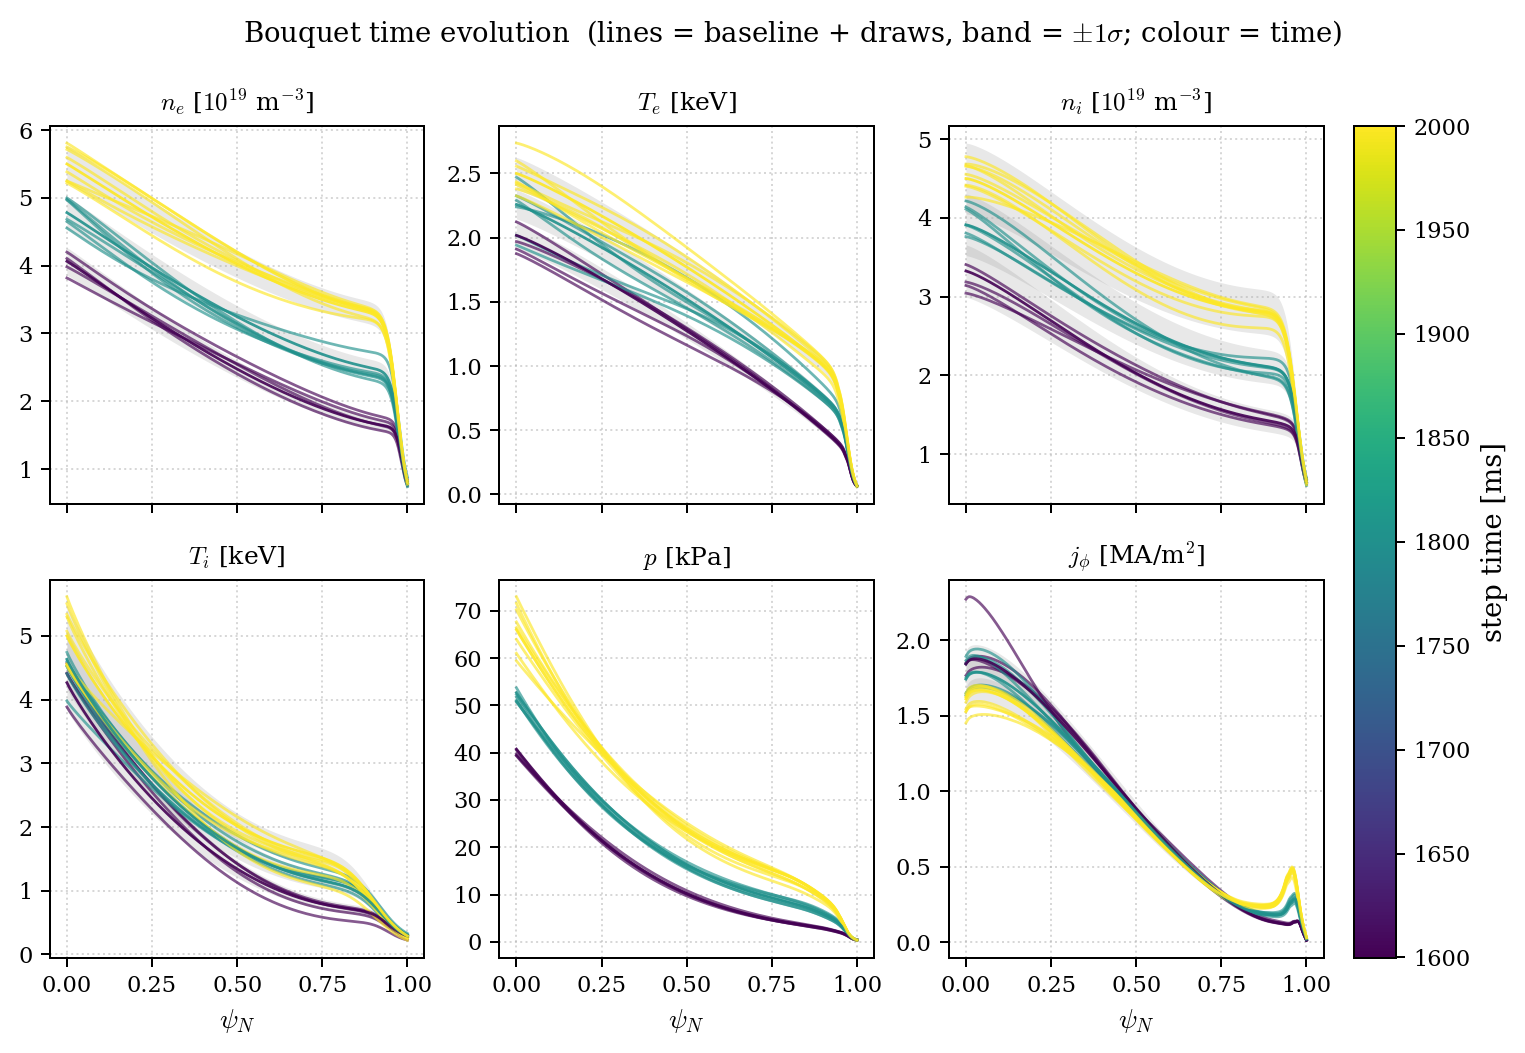

In [7]:
bq.plot_bouquet_timeseries(TS, time_label='step time [ms]')
plt.show()

## 6. Cluster: SLURM job array

On a multi-node cluster, swap `backend="slurm"`. Nothing runs — instead
`parallel_generate` serialises the run and writes a **job-array** sbatch (one
shard per task) plus a **dependent merge** job, both calling
`python -m bouquet.parallel` on the same `run_shard`. Submit with the generated
`*_submit.sh` (it chains them with `--dependency=afterok`).

On a cluster you'd typically use `threads_per_worker > 1` and more workers; set
`OMP_PROC_BIND`/`OMP_PLACES` (the script does) so each worker's threads stay on
one NUMA domain, and hold the BLAS thread count to match to avoid nested
oversubscription.

In [8]:
cfg = copy.deepcopy(template.config)
cfg.source.time         = 2.3043
cfg.generation.scan_key = 2000
cfg.generation.n_equils = 256           # a big ensemble worth a cluster
cfg.output_header       = 'D3Dlike_par_ts_2000ms'

paths = bq.parallel_generate(cfg, n_workers=32, threads_per_worker=4, seed=SEED,
                             backend="slurm",
                             slurm=dict(out_dir='slurm_jobs', job_name='bouquet_2000ms',
                                        partition=None, time_limit='02:00:00',
                                        mem_per_task='16G', python='python'))
print("wrote:", *paths.values(), sep="\n  ")
print("\n--- submit.sh ---")
print(open(paths['submit']).read())
print("--- array.sbatch ---")
print(open(paths['array']).read())

wrote:
  slurm_jobs/bouquet_2000ms_bundle.json
  slurm_jobs/bouquet_2000ms_array.sbatch
  slurm_jobs/bouquet_2000ms_merge.sbatch
  slurm_jobs/bouquet_2000ms_submit.sh

--- submit.sh ---
#!/bin/bash
# run from anywhere: everything below is relative to this script
cd "$(dirname "$0")"
# chain array + merge; afterany (not afterok) so the merge still
# runs -- and reports exactly which shards are missing -- after a
# partial array, instead of pending forever.
aid=$(sbatch --parsable bouquet_2000ms_array.sbatch)
sbatch --dependency=afterany:$aid bouquet_2000ms_merge.sbatch

--- array.sbatch ---
#!/bin/bash
#SBATCH --job-name=bouquet_2000ms
#SBATCH --array=0-31
#SBATCH --cpus-per-task=4
#SBATCH --time=02:00:00
#SBATCH --mem=16G
export OMP_NUM_THREADS=4
export OMP_PROC_BIND=close OMP_PLACES=cores
export OPENBLAS_NUM_THREADS=4 MKL_NUM_THREADS=4
python -m bouquet.parallel shard bouquet_2000ms_bundle.json $SLURM_ARRAY_TASK_ID



/Users/danielburgess/Desktop/plasma/bouquet/bouquet/parallel.py:366: UserWarning: threads_per_worker=4 sets nthreads=4 on every worker's TokaMaker. This breaks run-to-run determinism (~±1% li_1 jitter -> workers accept draws against different l_i targets) and risks DLSODE hangs on stiff slices. Use threads_per_worker=1 and more workers instead.
  return emit_slurm_script(


## Notes

- **Baseline guarantee.** `parallel_generate` asserts every worker's forward-solved
  `li`/`Ip` agree, so a stray `nthreads>1` or a mismatched source fails loudly
  rather than silently conditioning the ensemble on slightly different baselines.
- **Reproducibility.** Re-running with the same `SEED` reproduces the ensemble at
  `nthreads=1`. The parallel draw set differs from a *serial* run of the same seed
  (independent per-worker RNG streams) but is statistically equivalent.
- **Cleanup.** Per-worker shard files (`*_w*.h5`) are removed after the merge.